# EDA: Table Grid Detection ? From Mask to Contour Geometry

This notebook visualizes the actual contour path used by `detect_grid_tables()` on the aligned M2 page `train-00460_p01.jpg`. It follows the solution parameters: CLAHE ? inverted Otsu ? directional morphology ? OR ? 5?5 dilation ? `findContours(RETR_EXTERNAL, CHAIN_APPROX_SIMPLE)` ? `boundingRect`. No artificial degradation or rotation is applied.

In [ ]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

relative_image = Path("data/training_set/images/train-00460_p01.jpg")
image_path = next(
    (root / relative_image for root in (Path.cwd(), Path.cwd().parent, Path.cwd() / "Doc2Table")
     if (root / relative_image).is_file()),
    None,
)
if image_path is None:
    raise FileNotFoundError(f"Training image not found: {relative_image}")

gray = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
if gray is None:
    raise ValueError(f"Could not read: {image_path}")
height, width = gray.shape
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(gray)
binary = cv2.threshold(clahe, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]

horizontal = cv2.morphologyEx(
    binary, cv2.MORPH_OPEN,
    cv2.getStructuringElement(cv2.MORPH_RECT, (max(45, width // 18), 1)),
)
vertical = cv2.morphologyEx(
    binary, cv2.MORPH_OPEN,
    cv2.getStructuringElement(cv2.MORPH_RECT, (1, max(35, height // 45))),
)
joined = cv2.dilate(
    cv2.bitwise_or(horizontal, vertical),
    cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5)),
    iterations=1,
)

## Why contours? From pixels to table geometry

The joined mask represents the table as foreground pixels. `findContours` extracts its external boundary as an ordered point sequence. `boundingRect` then converts that contour into the candidate table location used by the solution. The last panel reports only geometry relevant to this pipeline: bounding box, width, height, and contour area.

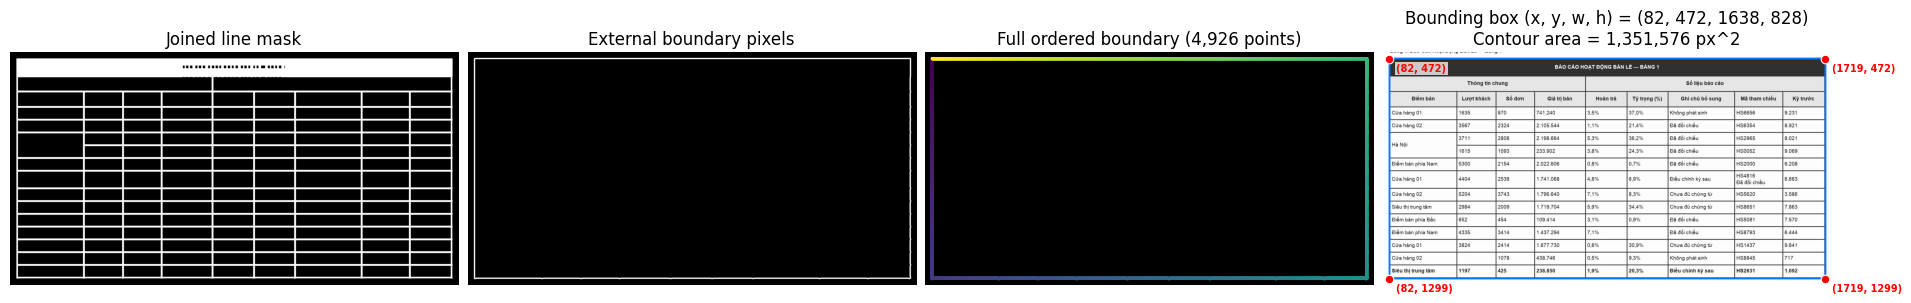

In [4]:
contours, _ = cv2.findContours(joined, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
candidates = []
for contour in contours:
    x, y, w, h = cv2.boundingRect(contour)
    if w >= width * 0.48 and h >= 80 and w * h >= width * height * 0.012:
        candidates.append(contour)
if not candidates:
    raise RuntimeError("No table contour passed the solution filters")
contour = max(candidates, key=cv2.contourArea)
x, y, w, h = cv2.boundingRect(contour)
pad = 24
x0, y0 = max(0, x - pad), max(0, y - pad)
x1, y1 = min(width, x + w + pad), min(height, y + h + pad)

boundary = np.zeros_like(joined)
cv2.drawContours(boundary, [contour], -1, 255, thickness=3)

# Keep CHAIN_APPROX_SIMPLE above for the actual solution geometry. For the
# teaching panel, retrieve every boundary pixel so the point order visibly
# runs around all four sides of the table.
full_contours, _ = cv2.findContours(joined, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
full_candidates = [
    item for item in full_contours
    if cv2.boundingRect(item) == (x, y, w, h)
]
full_contour = max(full_candidates, key=cv2.contourArea)
points = full_contour[:, 0, :]
ordered = np.zeros((height, width, 3), dtype=np.uint8)
cv2.polylines(ordered, [full_contour], isClosed=True, color=(210, 210, 210), thickness=2)
colors = plt.cm.viridis(np.linspace(0, 1, len(points)))[:, :3]

geometry = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
cv2.drawContours(geometry, [contour], -1, (255, 140, 0), thickness=4)
cv2.rectangle(geometry, (x, y), (x + w - 1, y + h - 1), (0, 120, 255), thickness=5)

fig, axes = plt.subplots(1, 4, figsize=(19, 5), layout="constrained")
axes[0].imshow(joined[y0:y1, x0:x1], cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Joined line mask")
axes[1].imshow(boundary[y0:y1, x0:x1], cmap="gray", vmin=0, vmax=255)
axes[1].set_title("External boundary pixels")
axes[2].imshow(ordered[y0:y1, x0:x1])
axes[2].scatter(points[:, 0] - x0, points[:, 1] - y0, c=colors, s=2)
axes[2].set_title(f"Full ordered boundary ({len(points):,} points)")
axes[3].imshow(geometry[y0:y1, x0:x1])
box_points = [
    (x, y),
    (x + w - 1, y),
    (x + w - 1, y + h - 1),
    (x, y + h - 1),
]
for point_x, point_y in box_points:
    local_x, local_y = point_x - x0, point_y - y0
    axes[3].scatter(local_x, local_y, s=38, color="red", edgecolor="white", linewidth=0.8)
    axes[3].annotate(
        f"({point_x}, {point_y})", (local_x, local_y),
        xytext=(5, -9), textcoords="offset points",
        color="red", fontsize=7, weight="bold",
        bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", pad=1),
    )
axes[3].set_title(
    f"Bounding box (x, y, w, h) = ({x}, {y}, {w}, {h})\n"
    f"Contour area = {cv2.contourArea(contour):,.0f} px^2"
)
for ax in axes:
    ax.axis("off")
plt.show()

**Interpretation:** the mask stores foreground pixels. The colored panel uses `CHAIN_APPROX_NONE` so every boundary pixel is visible in traversal order around the table. The actual localization path still uses `CHAIN_APPROX_SIMPLE`, which compresses straight runs before `boundingRect()` supplies `(x, y, w, h)`. The solution does not use centroid or shape classification here.

## How a contour is discovered

Raster scan and contour traversal are separate motions. The scan moves left to right and top to bottom until it reaches a foreground boundary. Border following then moves through neighboring boundary pixels until it returns to the start. This simplified mask has one object and uses `RETR_EXTERNAL` with `CHAIN_APPROX_NONE`.

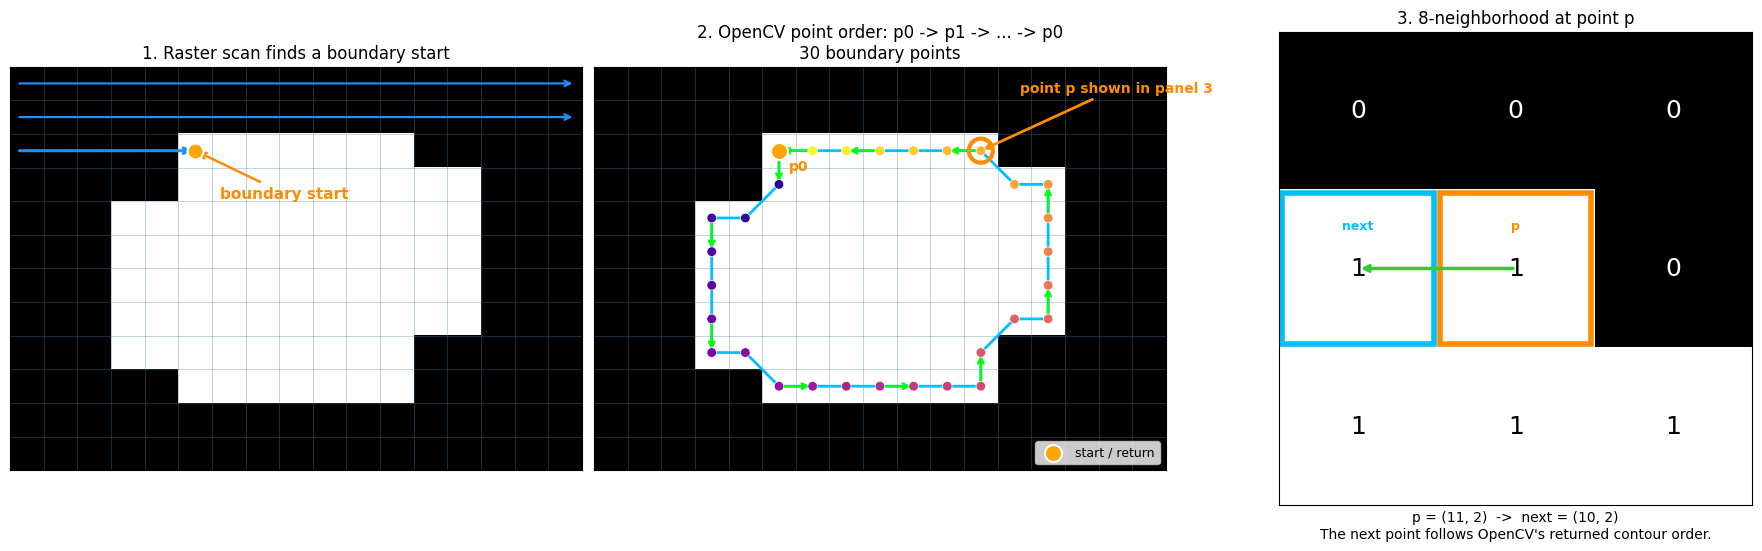

In [8]:
# A small binary mask keeps the two motions easy to see.
scan_mask = np.zeros((12, 17), dtype=np.uint8)
object_polygon = np.array([
    [5, 2], [11, 2], [11, 3], [13, 3], [13, 7],
    [11, 7], [11, 9], [5, 9], [5, 8], [3, 8], [3, 4], [5, 4],
], dtype=np.int32)
cv2.fillPoly(scan_mask, [object_polygon], 255)
scan_contours, _ = cv2.findContours(
    scan_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE
)
scan_contour = max(scan_contours, key=cv2.contourArea)
ordered_points = scan_contour[:, 0, :]
start_x, start_y = map(int, ordered_points[0])

fig, axes = plt.subplots(1, 3, figsize=(18, 5.4), layout="constrained")
for ax in axes[:2]:
    ax.imshow(scan_mask, cmap="gray", vmin=0, vmax=255, origin="upper")
    ax.set_xticks(np.arange(-0.5, scan_mask.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, scan_mask.shape[0], 1), minor=True)
    ax.grid(which="minor", color="steelblue", alpha=0.35, linewidth=0.7)
    ax.tick_params(which="both", bottom=False, left=False,
                   labelbottom=False, labelleft=False)

# Panel 1: stop the raster scan as soon as the first boundary pixel is found.
for row in range(start_y):
    axes[0].annotate(
        "", xy=(scan_mask.shape[1] - 0.7, row), xytext=(-0.3, row),
        arrowprops=dict(arrowstyle="->", color="dodgerblue", lw=1.6),
    )
axes[0].annotate(
    "", xy=(start_x, start_y), xytext=(-0.3, start_y),
    arrowprops=dict(arrowstyle="->", color="dodgerblue", lw=2.2),
)
axes[0].scatter(start_x, start_y, s=130, facecolor="orange",
                edgecolor="white", linewidth=1.5, zorder=5)
axes[0].annotate(
    "boundary start", (start_x, start_y), xytext=(18, -34),
    textcoords="offset points", color="darkorange", fontsize=11, weight="bold",
    arrowprops=dict(arrowstyle="->", color="darkorange", lw=1.8),
)
axes[0].set_title("1. Raster scan finds a boundary start")

# Panel 2: show the actual point order returned by OpenCV.
order_colors = plt.cm.plasma(np.linspace(0, 1, len(ordered_points)))
axes[1].plot(
    np.r_[ordered_points[:, 0], ordered_points[0, 0]],
    np.r_[ordered_points[:, 1], ordered_points[0, 1]],
    color="deepskyblue", linewidth=2,
)
axes[1].scatter(ordered_points[:, 0], ordered_points[:, 1],
                c=order_colors, s=48, edgecolor="white", linewidth=0.5, zorder=4)
step = max(1, len(ordered_points) // 8)
arrow_indices = list(range(0, len(ordered_points), step))
if len(ordered_points) - 1 not in arrow_indices:
    arrow_indices.append(len(ordered_points) - 1)  # show closure back to p0
for index in arrow_indices:
    current = ordered_points[index]
    following = ordered_points[(index + 1) % len(ordered_points)]
    axes[1].annotate(
        "", xy=following, xytext=current,
        arrowprops=dict(arrowstyle="->", color="lime", lw=1.7),
    )
axes[1].scatter(start_x, start_y, s=150, facecolor="orange",
                edgecolor="white", linewidth=1.5, zorder=6, label="start / return")
axes[1].annotate("p0", (start_x, start_y), xytext=(7, -14),
                 textcoords="offset points", color="darkorange", weight="bold")
axes[1].legend(loc="lower right", fontsize=9)
axes[1].set_title(
    f"2. OpenCV point order: p0 -> p1 -> ... -> p0\n"
    f"{len(ordered_points)} boundary points"
)

# Select the rightmost point on the top boundary: this is the point p
# highlighted near the upper-right corner in panel 2.
top_y = ordered_points[:, 1].min()
top_indices = np.flatnonzero(ordered_points[:, 1] == top_y)
focus_index = top_indices[np.argmax(ordered_points[top_indices, 0])]
point_x, point_y = map(int, ordered_points[focus_index])
next_x, next_y = map(int, ordered_points[(focus_index + 1) % len(ordered_points)])

axes[1].scatter(point_x, point_y, s=300, facecolor="none",
                edgecolor="darkorange", linewidth=3, zorder=7)
axes[1].annotate(
    "point p shown in panel 3", (point_x, point_y), xytext=(28, 42),
    textcoords="offset points", color="darkorange", fontsize=10, weight="bold",
    arrowprops=dict(arrowstyle="->", color="darkorange", lw=2),
)

# Panel 3: show the local 8-neighborhood around that upper-right point p.
neighborhood = (scan_mask[point_y - 1:point_y + 2,
                          point_x - 1:point_x + 2] > 0).astype(np.uint8)
next_col = next_x - point_x + 1
next_row = next_y - point_y + 1

axes[2].imshow(neighborhood, cmap="gray", vmin=0, vmax=1, origin="upper")
axes[2].set_xticks(np.arange(-0.5, 3, 1), minor=True)
axes[2].set_yticks(np.arange(-0.5, 3, 1), minor=True)
axes[2].grid(which="minor", color="navy", linewidth=1.2)
axes[2].tick_params(which="both", bottom=False, left=False,
                    labelbottom=False, labelleft=False)
for row in range(3):
    for col in range(3):
        axes[2].text(col, row, str(neighborhood[row, col]),
                     ha="center", va="center", fontsize=18,
                     color="black" if neighborhood[row, col] else "white")
for col, row, color, label in (
    (1, 1, "darkorange", "p"),
    (next_col, next_row, "deepskyblue", "next"),
):
    axes[2].add_patch(
        plt.Rectangle((col - 0.48, row - 0.48), 0.96, 0.96,
                      fill=False, edgecolor=color, linewidth=4)
    )
    axes[2].text(col, row - 0.27, label, ha="center", va="center",
                 fontsize=9, color=color, weight="bold")
axes[2].annotate("", xy=(next_col, next_row), xytext=(1, 1),
                 arrowprops=dict(arrowstyle="->", color="limegreen", lw=2.5))
axes[2].set_title("3. 8-neighborhood at point p")
axes[2].set_xlabel(
    f"p = ({point_x}, {point_y})  ->  next = ({next_x}, {next_y})\n"
    "The next point follows OpenCV's returned contour order.",
    fontsize=10,
)

plt.show()


## 5.1 Recover global grid edges

The vertical and horizontal line masks are projected onto their corresponding coordinate axes. High-response positions are grouped into line runs, reduced to edge coordinates, deduplicated, and supplemented with the contour bounding box when an outer border is missing.


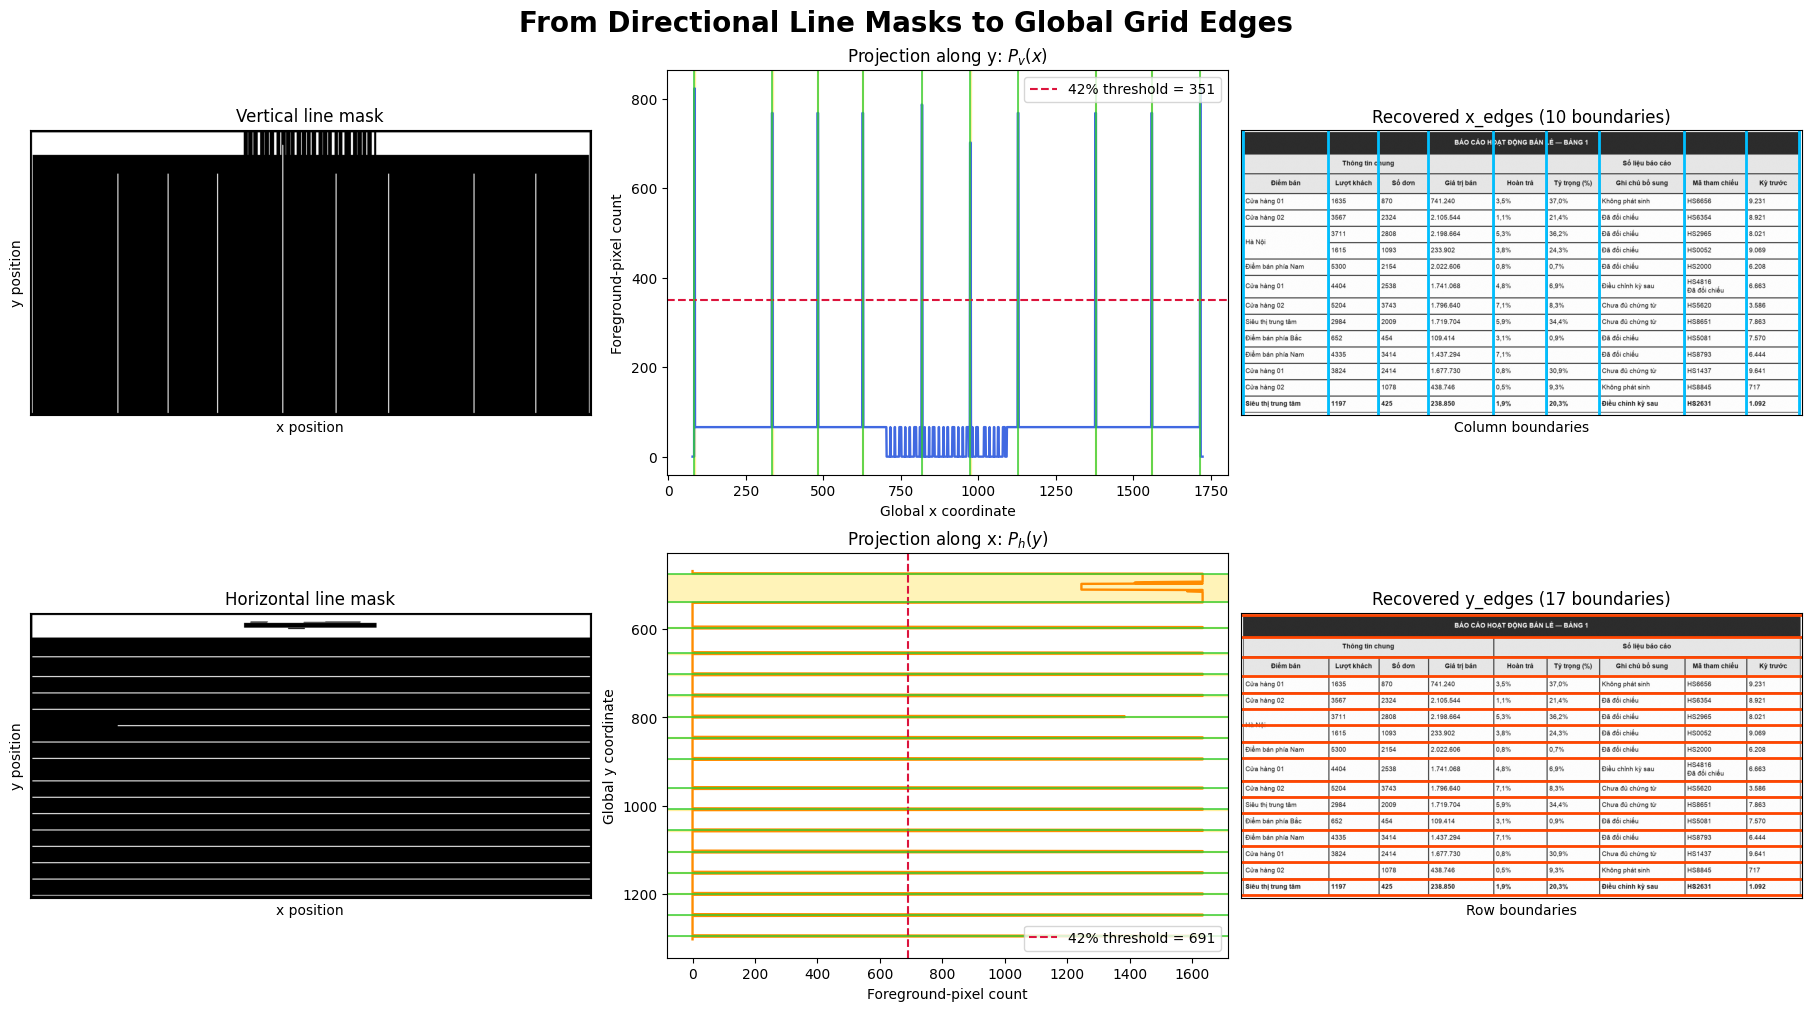

In [9]:
# Use the same projection and edge-recovery rules as the solution.
def projection_runs(active, gap=3):
    indices = np.flatnonzero(active)
    if indices.size == 0:
        return []
    runs = []
    start = previous = int(indices[0])
    for raw in indices[1:]:
        value = int(raw)
        if value - previous > gap:
            runs.append((start, previous))
            start = value
        previous = value
    runs.append((start, previous))
    return runs


def dedupe_edges(values, tolerance=6):
    groups = [[values[0]]]
    for value in values[1:]:
        if value - groups[-1][-1] <= tolerance:
            groups[-1].append(value)
        else:
            groups.append([value])
    return [round(sum(group) / len(group)) for group in groups]


def recover_edges(mask, axis, extent, offset):
    projection = np.count_nonzero(mask, axis=axis)
    threshold = max(8, round(extent * 0.42))
    runs = projection_runs(projection >= threshold, gap=3)
    local_edges = []
    for start, end in runs:
        if end - start >= 9:       # wide dark band: retain both boundaries
            local_edges.extend((start, end))
        else:                      # ordinary line: retain its centre
            local_edges.append(round((start + end) / 2))
    return projection, threshold, runs, dedupe_edges(
        [offset + edge for edge in local_edges]
    )


# The production code uses a four-pixel crop around the detected table box.
roi_x0, roi_y0 = max(0, x - 4), max(0, y - 4)
roi_x1, roi_y1 = min(width, x + w + 4), min(height, y + h + 4)
local_vertical = vertical[roi_y0:roi_y1, roi_x0:roi_x1]
local_horizontal = horizontal[roi_y0:roi_y1, roi_x0:roi_x1]

x_projection, x_threshold, x_runs, x_edges = recover_edges(
    local_vertical, axis=0, extent=roi_y1 - roi_y0, offset=roi_x0
)
y_projection, y_threshold, y_runs, y_edges = recover_edges(
    local_horizontal, axis=1, extent=roi_x1 - roi_x0, offset=roi_y0
)

# Recover missing outer borders from the contour bounding box.
if abs(x_edges[0] - x) > 10:
    x_edges.insert(0, x)
if abs(x_edges[-1] - (x + w - 1)) > 10:
    x_edges.append(x + w - 1)
if abs(y_edges[0] - y) > 10:
    y_edges.insert(0, y)
if abs(y_edges[-1] - (y + h - 1)) > 10:
    y_edges.append(y + h - 1)

x_coordinates = np.arange(roi_x0, roi_x1)
y_coordinates = np.arange(roi_y0, roi_y1)
table_crop = gray[roi_y0:roi_y1, roi_x0:roi_x1]

fig, axes = plt.subplots(2, 3, figsize=(18, 10), layout="constrained")

# Row 1: vertical mask -> x projection -> recovered column boundaries.
axes[0, 0].imshow(local_vertical, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title("Vertical line mask")
axes[0, 0].set_xlabel("x position")
axes[0, 0].set_ylabel("y position")

axes[0, 1].plot(x_coordinates, x_projection, color="royalblue", lw=1.7)
axes[0, 1].axhline(x_threshold, color="crimson", ls="--",
                   label=f"42% threshold = {x_threshold}")
for start, end in x_runs:
    axes[0, 1].axvspan(roi_x0 + start, roi_x0 + end,
                       color="gold", alpha=0.28)
for edge in x_edges:
    axes[0, 1].axvline(edge, color="limegreen", lw=1.2, alpha=0.9)
axes[0, 1].set_title("Projection along y: $P_v(x)$")
axes[0, 1].set_xlabel("Global x coordinate")
axes[0, 1].set_ylabel("Foreground-pixel count")
axes[0, 1].legend(loc="upper right")

axes[0, 2].imshow(table_crop, cmap="gray")
for edge in x_edges:
    axes[0, 2].axvline(edge - roi_x0, color="deepskyblue", lw=2)
axes[0, 2].set_title(f"Recovered x_edges ({len(x_edges)} boundaries)")
axes[0, 2].set_xlabel("Column boundaries")

# Row 2: horizontal mask -> y projection -> recovered row boundaries.
axes[1, 0].imshow(local_horizontal, cmap="gray", vmin=0, vmax=255)
axes[1, 0].set_title("Horizontal line mask")
axes[1, 0].set_xlabel("x position")
axes[1, 0].set_ylabel("y position")

axes[1, 1].plot(y_projection, y_coordinates, color="darkorange", lw=1.7)
axes[1, 1].axvline(y_threshold, color="crimson", ls="--",
                   label=f"42% threshold = {y_threshold}")
for start, end in y_runs:
    axes[1, 1].axhspan(roi_y0 + start, roi_y0 + end,
                       color="gold", alpha=0.28)
for edge in y_edges:
    axes[1, 1].axhline(edge, color="limegreen", lw=1.2, alpha=0.9)
axes[1, 1].invert_yaxis()
axes[1, 1].set_title("Projection along x: $P_h(y)$")
axes[1, 1].set_xlabel("Foreground-pixel count")
axes[1, 1].set_ylabel("Global y coordinate")
axes[1, 1].legend(loc="lower right")

axes[1, 2].imshow(table_crop, cmap="gray")
for edge in y_edges:
    axes[1, 2].axhline(edge - roi_y0, color="orangered", lw=2)
axes[1, 2].set_title(f"Recovered y_edges ({len(y_edges)} boundaries)")
axes[1, 2].set_xlabel("Row boundaries")

for ax in (axes[0, 0], axes[0, 2], axes[1, 0], axes[1, 2]):
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(
    "From Directional Line Masks to Global Grid Edges",
    fontsize=20,
    fontweight="bold",
)
plt.show()
